In [1]:
import wandb
from wandb import Api
import pandas as pd
import numpy as np

In [ ]:
api = Api()
runs = api.runs("jangrove-jg-university-of-amsterdam/WeakBE-Net_no_ind")

In [ ]:
runs

<Runs jangrove-jg-university-of-amsterdam/WeakBE-Net_no_ind>

In [ ]:
# for run in runs:
#     run_id = run.id
#     config = run.config
#     summary = run.summary
#     history = run.history(keys=['val_loss', 'val_accuracy']
#         )
    
#     history_df = pd.DataFrame(history)
    
#     history_df.to_csv(f"../../../experiments/histories/{run_id}_history.csv", index=False)
    
#     print(f"Run ID: {run_id}")
#     print(f"Summary: {summary}")

Run ID: convmetrics_Pathologist_1_fold_1
Summary: {'Confusion Matrix': {'_type': 'image-file', 'format': 'png', 'height': 700, 'path': 'media/images/Confusion Matrix_97051_5b3f6d7b27fe975bbf25.png', 'sha256': '5b3f6d7b27fe975bbf2572ea97bf6509e3bc9163decd73804fbe3857dfe8e88c', 'size': 23692, 'width': 700}, '_runtime': 527.186599079, '_step': 97052, '_timestamp': 1746463470.7609727, '_wandb': {'runtime': 527}, 'epoch': 150, 'final_val_HGD_auc': 0.952250599861145, 'final_val_HGD_f1': 0.6285714507102966, 'final_val_HGD_precision': 1, 'final_val_HGD_recall': 0.4583333432674408, 'final_val_LGD_auc': 0.8407207131385803, 'final_val_LGD_f1': 0.6857143044471741, 'final_val_LGD_precision': 0.6545454263687134, 'final_val_LGD_recall': 0.7200000286102295, 'final_val_NDBE_auc': 0.9346070289611816, 'final_val_NDBE_f1': 0.8901098966598511, 'final_val_NDBE_precision': 0.8526315689086914, 'final_val_NDBE_recall': 0.931034505367279, 'final_val_accuracy': 0.7950310707092285, 'fold/convergence_epoch': 16, '

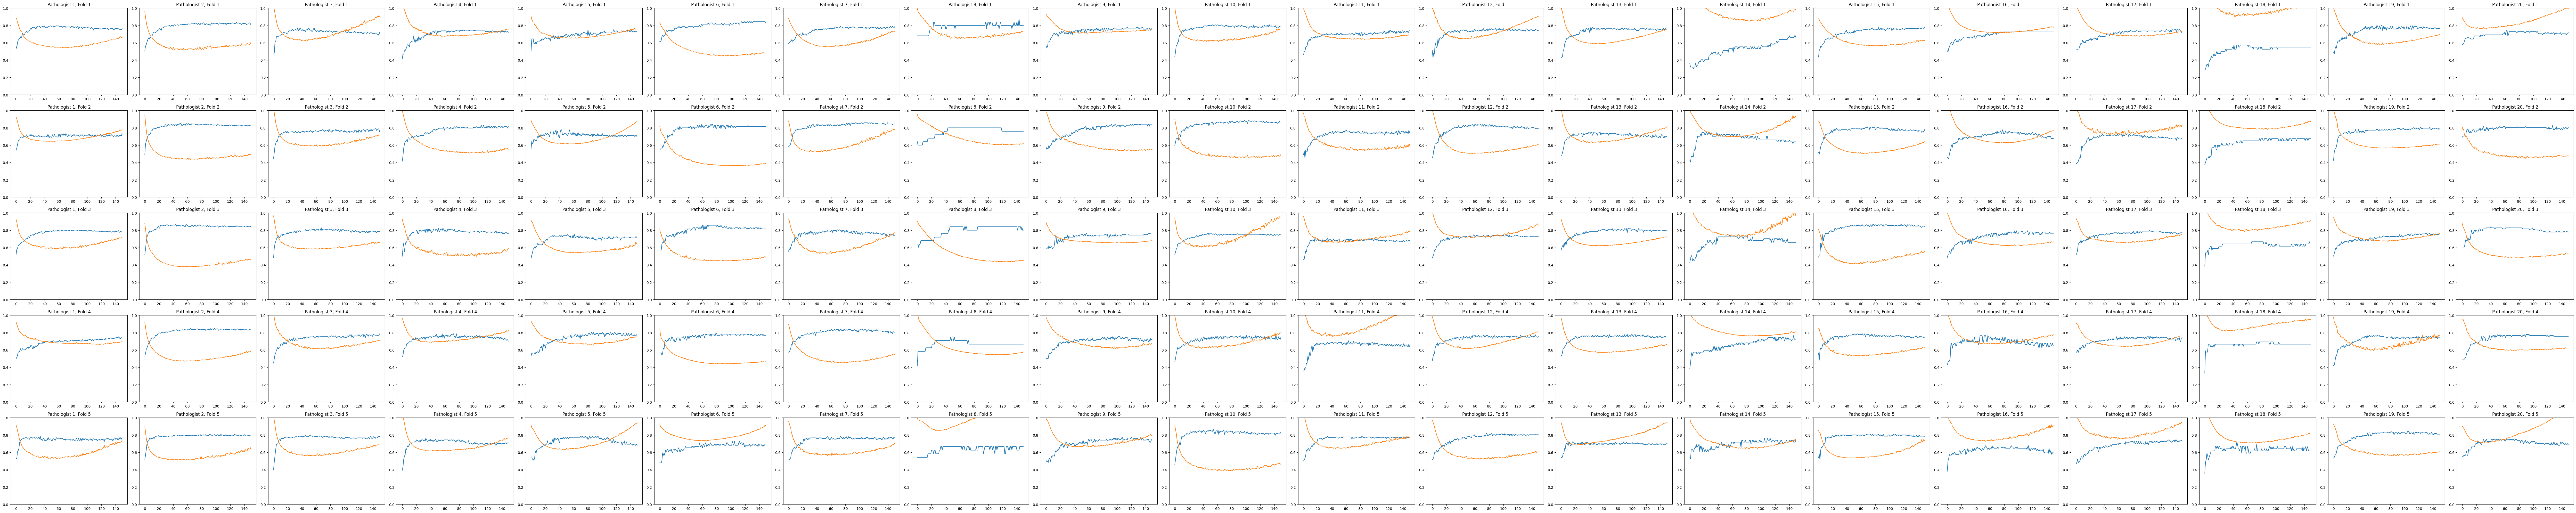

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 20, figsize=(100, 20))
model_dfs = {}  # Change model_dfs from list to dictionary

for path_id in range(1, 21):
    for fold_id in range(1, 6):
        df = pd.read_csv(f"../../../experiments/histories/convmetrics_Pathologist_{path_id}_fold_{fold_id}_history.csv")
        loss_df = df["val_loss"]
        acc_df = df["val_accuracy"]

        model_dfs[(path_id, fold_id)] = df  # Store df in the dictionary with (path_id, fold_id) as the key

        axes[fold_id-1, path_id-1].plot(acc_df, label=f"Pathologist {path_id}, Fold {fold_id}")
        axes[fold_id-1, path_id-1].plot(loss_df, label=f"Pathologist {path_id}, Fold {fold_id}")
        axes[fold_id-1, path_id-1].set_title(f"Pathologist {path_id}, Fold {fold_id}")
        axes[fold_id-1, path_id-1].set_ylim(0, 1)  # Set y-axis limits

plt.tight_layout()
plt.show()


In [11]:
pd.read_csv(f"../../../experiments/histories/convmetrics_Pathologist_{path_id}_fold_{fold_id}_history.csv")

,_step,val_loss,val_accuracy
0,326,0.900590,0.5500
1,654,0.888734,0.5500
2,982,0.877398,0.5625
3,1310,0.862248,0.5625
4,1638,0.845369,0.5625
...,...,...,...
145,47886,1.091956,0.7000
146,48214,1.098983,0.6875
147,48542,1.103864,0.6875
148,48870,1.111545,0.7000


In [15]:
def assess_convergence(df, metric='val_loss', window=10, slope_threshold=0.01, std_threshold=0.01):
    y = df[metric].iloc[-window:].values
    x = np.arange(window)

    slope = np.polyfit(x, y, 1)[0]
    std_dev = np.std(y)

    converged = abs(slope) < slope_threshold and std_dev < std_threshold

    return {
        f'{metric}_slope': slope,
        f'{metric}_std': std_dev,
        f'{metric}_converged': converged
    }

def assess_all_models(model_dfs, window=10):
    results = []

    for (model, fold), df in model_dfs.items():
        res_loss = assess_convergence(df, metric='val_loss', window=window)
        res_acc = assess_convergence(df, metric='val_accuracy', window=window,
                                     slope_threshold=0.001, std_threshold=0.005)  # tighter for acc

        results.append({
            'model': model,
            'fold': fold,
            **res_loss,
            **res_acc
        })

    return pd.DataFrame(results)

In [18]:
assess_all_models(model_dfs, window=10).to_csv("convergence_assessment.csv", index=False)